# Topical Lectures, Controls
## Drone control, part 3b: adding a velocity loop

Andreas Freise, 27.05.2026

The cascade in notebook 3 had one ugly seam: the y position PID
produced a number with no defined units, and we treated it as a
desired tilt angle. We compensated by clipping at $\pm 0.2\pi$.
The connection between gain choice and "how hard the drone tilts"
was only correct by accident.

In this notebook we fix that by inserting a *velocity loop* between
the position controller and the attitude controller. The cascade
becomes:

```
position PID  -> desired velocity (m/s, clipped at +-1 m/s)
velocity PID  -> desired tilt    (rad,   clipped at +-20 deg)
phi PID       -> torque command  (motor differential)
```

Each loop now has clear physical units, and the saturation limits
have an obvious meaning. This is the architecture the real Crazyflie
firmware uses (see `docs/matecconf_rapdasa2025_04007.md`, Section 3),
minus a fourth attitude-rate loop that runs at 500 Hz inside the
microcontroller and that we deliberately do not model here.


In [1]:
# Importing packages
import numpy as np
import matplotlib.pyplot as plt
import time
import module
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

%matplotlib inline

MyName = "Andreas"


## Drone parameters and helpers

Same constants and motor-mixing helpers as the racing notebooks.


In [2]:
V_left_offset = -0.0027
V_hover = 0.5297
V_max = 1.0
V_min = 0

def set_v_nohover(drone, _V_left, _V_right):
    V_left = _V_left + V_left_offset
    V_right = _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def zphi2V(fb_z, fb_phi):
    return fb_z + fb_phi, fb_z - fb_phi


## The velocity-loop cascade

We use the same `module.PIDController` class four times: one for each
position axis, one for each velocity axis. The phi controller is the
same PD we used in notebook 3.

Sign convention for the new loops is worth working out explicitly:

* **Position loop (y or z):** `err = state.y - y0`. If the drone is
  *above* its setpoint we want a *negative* desired velocity, so we
  pick a *negative* `Kp` for the position controller.
* **Velocity loop, y:** `err = state.dy - dy_des`. If the drone is
  moving right faster than commanded, we want positive tilt (drone
  tips right, accelerates left). Positive `Kp`.
* **Velocity loop, z:** `err = state.dz - dz_des`. If the drone is
  climbing faster than commanded, we want less thrust. Negative `Kp`.

The saturation limits come straight from the CF firmware: $\pm 1$ m/s
on commanded velocity and $\pm 20°$ on commanded tilt.


In [3]:
# Position -> velocity (P-only is fine; the integrator lives in the
# inner velocity loop, where it can compensate steady-state errors).
y_pos_ctrl = module.PIDController(Kp=-2.0, Ki=0, Kd=0)
z_pos_ctrl = module.PIDController(Kp=-2.0, Ki=0, Kd=0)

# Velocity -> tilt / thrust correction. PI: integrator handles biases.
y_vel_ctrl = module.PIDController(Kp=0.5,  Ki=0.02, Kd=0)
z_vel_ctrl = module.PIDController(Kp=-3.0, Ki=-0.3, Kd=0)

# Inner phi PD, same as Layer A.
phi_ctrl   = module.PIDController(Kp=0.2, Ki=0, Kd=0.04)

# Saturation limits, taken from the CF firmware.
v_max_cmd = 1.0           # m/s, max commanded velocity
tilt_max  = 20 * np.pi / 180   # rad, max commanded tilt (20 deg)


## Where the velocity loop wins: a large position step

To see the difference between the flat cascade from notebook 3 and the velocity-loop cascade above, we step the y-setpoint from 0 to 2.5 m and run the simulation twice with the same drone, once with each controller. The z-setpoint stays at zero.

Two simulator settings matter for this demonstration:

* `wind=False`, so the comparison is about the controllers, not about disturbance rejection.
* `drag_t=0`, so we can actually see what each controller would do without the simulator's drag quietly capping the drone's speed for us. In the racing notebooks we keep drag on (it is what makes the Crazyflie's motion realistic); but for the lesson here we want the controller alone to decide how fast the drone goes.

For the **flat cascade** (no velocity loop), the position PID's output is interpreted directly as a tilt command and clipped at $\pm 20°$. The drone tilts to the clip, accelerates, and the only thing that brings it back is the position error swinging the other way once it overshoots.

For the **velocity-loop cascade**, the position PID's output is interpreted as a desired *velocity*, clipped at $\pm v_{\mathrm{max}} = 1$ m/s. The inner velocity loop then turns that into the tilt needed to reach $v_{\mathrm{max}}$, and stops adding tilt once the drone is there. The drone cruises at the speed limit and brakes cleanly into the setpoint.

In [4]:
# Step from y=0 to y=2.5, hold z=0. Wind off and drag off so we see
# the controllers' behaviour rather than the simulator's drag.
y_setpoint = 2.5
z_setpoint = 0.0
T_run = 8.0
N = int(T_run * 60)


# --- Flat cascade (the controller from notebook 3) -----------------
# Position PID outputs a tilt command directly, clipped at +-20 deg.
y_PID_flat   = module.PIDController(Kp=1.5,  Ki=0,    Kd=0.3)
z_PID_flat   = module.PIDController(Kp=-2.0, Ki=-0.2, Kd=-1.0)
phi_PID_flat = module.PIDController(Kp=0.2,  Ki=0,    Kd=0.04)
tilt_max_flat = np.deg2rad(20)

drone = module.Drone(name=MyName, wind=False,
                     flight_range=(-5, -3, 5, 3),
                     drag_t=0, drag_r=5)
results_flat = np.zeros([N, 14])
V_l = V_r = 0
for ctrl in (y_PID_flat, z_PID_flat, phi_PID_flat):
    ctrl.reset()
for i in range(N):
    state = drone.update()
    results_flat[i, 0:12] = module.state_to_array(state)
    results_flat[i, 12:14] = [V_l, V_r]

    # Position PID -> tilt command directly (the seam from notebook 3).
    tilt_des = float(np.clip(y_PID_flat(state.y, state.dy, y_setpoint),
                             -tilt_max_flat, tilt_max_flat))
    z_corr   = z_PID_flat(state.z, state.dz, z_setpoint)
    phi_fb   = phi_PID_flat(state.phi, state.dphi, tilt_des)
    hover_ff = V_hover / np.cos(state.phi)
    V_l, V_r = zphi2V(hover_ff + z_corr, phi_fb)
    set_v_nohover(drone, V_l, V_r)


# --- Velocity-loop cascade (defined above) -------------------------
drone = module.Drone(name=MyName, wind=False,
                     flight_range=(-5, -3, 5, 3),
                     drag_t=0, drag_r=5)
results_vel = np.zeros([N, 14])
V_l = V_r = 0
for ctrl in (y_pos_ctrl, z_pos_ctrl, y_vel_ctrl, z_vel_ctrl, phi_ctrl):
    ctrl.reset()
for i in range(N):
    state = drone.update()
    results_vel[i, 0:12] = module.state_to_array(state)
    results_vel[i, 12:14] = [V_l, V_r]

    # Position PID -> desired velocity, capped at v_max_cmd.
    dy_des = float(np.clip(y_pos_ctrl(state.y, state.dy, y_setpoint),
                           -v_max_cmd, v_max_cmd))
    dz_des = float(np.clip(z_pos_ctrl(state.z, state.dz, z_setpoint),
                           -v_max_cmd, v_max_cmd))
    # Velocity PID -> desired tilt, capped at tilt_max.
    tilt_des = float(np.clip(y_vel_ctrl(state.dy, 0, dy_des),
                             -tilt_max, tilt_max))
    z_corr   = z_vel_ctrl(state.dz, 0, dz_des)
    phi_fb   = phi_ctrl(state.phi, state.dphi, tilt_des)
    hover_ff = V_hover / np.cos(state.phi)
    V_l, V_r = zphi2V(hover_ff + z_corr, phi_fb)
    set_v_nohover(drone, V_l, V_r)

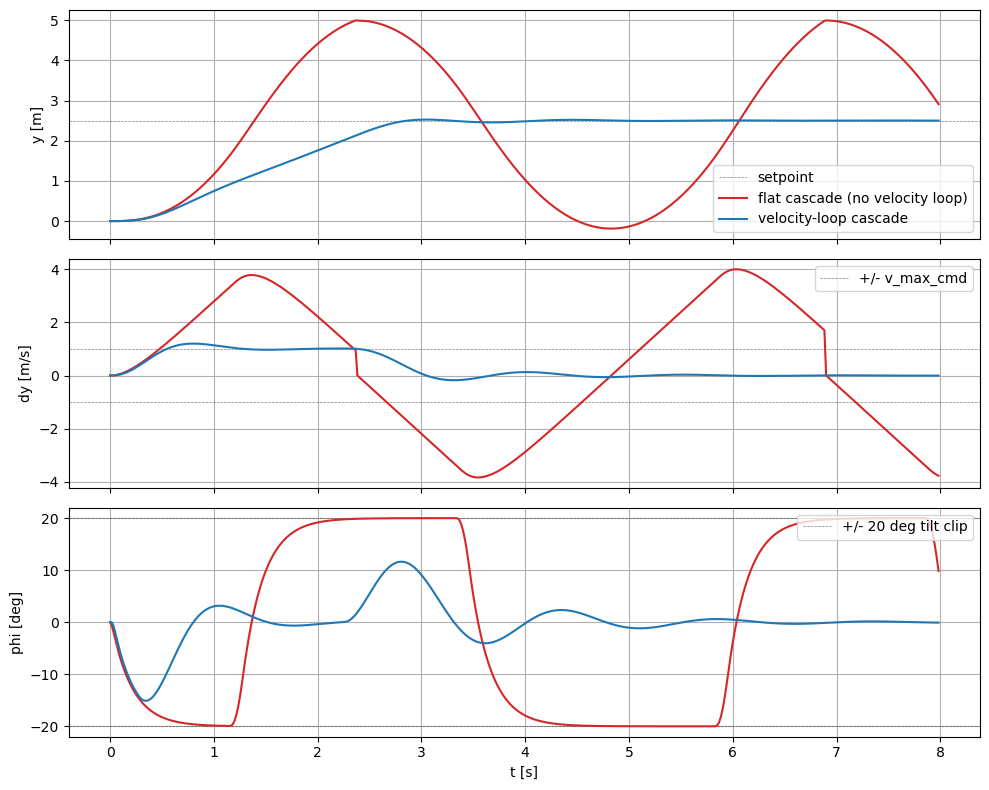

In [5]:
# Compare the two controllers on the same step: position, velocity, tilt.
t = np.arange(N) / 60.0
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].axhline(y_setpoint, color='k', lw=0.5, ls='--', alpha=0.5, label='setpoint')
axes[0].plot(t, results_flat[:, 1], color='C3', label='flat cascade (no velocity loop)')
axes[0].plot(t, results_vel[:,  1], color='C0', label='velocity-loop cascade')
axes[0].set_ylabel('y [m]')
axes[0].legend(loc='lower right')
axes[0].grid()

axes[1].axhline( v_max_cmd, color='k', lw=0.5, ls='--', alpha=0.5)
axes[1].axhline(-v_max_cmd, color='k', lw=0.5, ls='--', alpha=0.5, label='+/- v_max_cmd')
axes[1].plot(t, results_flat[:, 4], color='C3')
axes[1].plot(t, results_vel[:,  4], color='C0')
axes[1].set_ylabel('dy [m/s]')
axes[1].legend(loc='upper right')
axes[1].grid()

axes[2].axhline( np.rad2deg(tilt_max), color='k', lw=0.5, ls='--', alpha=0.5)
axes[2].axhline(-np.rad2deg(tilt_max), color='k', lw=0.5, ls='--', alpha=0.5, label='+/- 20 deg tilt clip')
axes[2].plot(t, np.rad2deg(results_flat[:, 3]), color='C3')
axes[2].plot(t, np.rad2deg(results_vel[:,  3]), color='C0')
axes[2].set_ylabel('phi [deg]')
axes[2].set_xlabel('t [s]')
axes[2].legend(loc='upper right')
axes[2].grid()

plt.tight_layout()

## What we just saw

The flat cascade hits the tilt clip, accelerates the drone to several m/s, and overshoots the setpoint by 1 m or more before braking. The velocity cascade respects $v_{\mathrm{max}} = 1$ m/s as a hard upper bound on the drone's *speed*, cruises through the middle of the move at that speed, and brakes into the setpoint with no overshoot.

Two reasons the velocity loop wins as a building block:

1. **The saturation lives at the right layer.** $v_{\mathrm{max}} = 1$ m/s is a physical bound on the drone's speed. The $\pm 20°$ tilt clip in the flat cascade was a bound on a dimensionless feedback signal whose relationship to speed depends on the gain.

2. **The velocity loop gives natural damping.** When the drone is moving faster than commanded, the velocity error directly produces a tilt with the right sign and magnitude to brake. The flat cascade had to wait for a position error to swing the other way before it could do anything about excess speed.

In the racing notebooks the simulator's drag (`drag_t=4`) is on by default. It quietly caps the drone's velocity for us, which is why the flat cascade in notebook 3 looked passable: the drone never actually got fast enough for the lack of an explicit speed cap to bite. With drag off, as in the demo above, the flat cascade flies off the rails. The lesson is that you should not rely on whatever drag your real platform happens to have, but build a speed cap into the controller itself.

This is the architecture the real Crazyflie firmware uses (see `docs/matecconf_rapdasa2025_04007.md`, Section 3), minus a fourth attitude-rate loop that runs at 500 Hz inside the microcontroller and that we deliberately do not model here.

From the next notebook onwards every notebook runs the same five-target race so you can compare. Notebook `student4a` lets you fly the race yourself (interactively, via keyboard control on the setpoint) and `student4b` runs the velocity-loop cascade headlessly. After that, `student5` introduces algebraic inversion of the dynamics, and `student6` adds smooth fly-through trajectories on top. Each one races the same track, so the videos compare directly.